# Import libraries

In [9]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

# Load data

In [13]:
df = pd.read_parquet("../data/merged_data.parquet")

# Feature engineering

## Missing values

In [22]:
df = df.ffill()

## Date features

In [23]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0
        
def is_new_years(timestamp) -> bool:
    if ((timestamp.month == 12 and timestamp.day_of_week == 31) 
        or 
        (timestamp.month == 1 and timestamp.day_of_week == 1)):
        return True
    else:
        return False

In [24]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['is_new_year'] = df["timestamp"].apply(lambda x: is_new_years(x))

## Rolling & lag

In [30]:
df = df.rename(columns={"value": "pm25"})

In [31]:
target = 'pm25'
lag_periods = [3, 6]
rolling_window = [3]

In [32]:
for window in rolling_window:
    df[f'rolling_{target}_{str(window)}'] = df[target].rolling(window=window).mean()

for period in lag_periods:
    df[f'lag_{target}_{str(period)}'] = df[target].shift(periods=period)

## Shifted target

In [43]:
df['target'] = df[target].shift(-6)

# Create data splits

In [44]:
df = df.dropna()

In [45]:
train_idx = int(np.ceil(len(df) * .9))
print(train_idx)

657


In [46]:
train_df = df.loc[:train_idx, :]
test_df = df.loc[train_idx:, :]

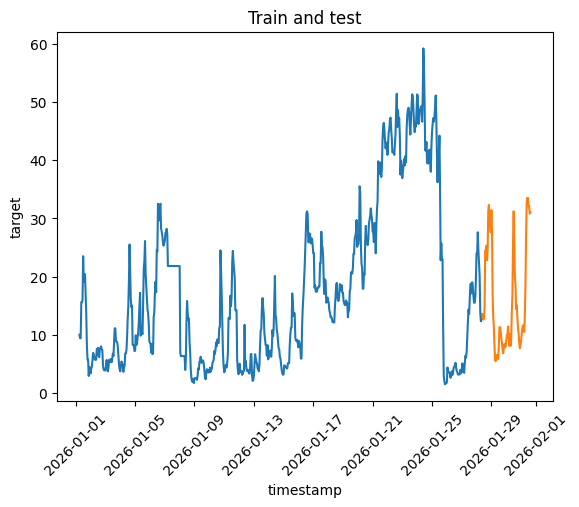

In [47]:
sns.lineplot(train_df, x="timestamp", y="target")
sns.lineplot(test_df, x="timestamp", y="target")
plt.title("Train and test")
plt.xticks(rotation=45)
plt.show()

In [48]:
X_train = train_df.drop(['timestamp', 'target'], axis=1)
y_train = train_df.loc[:, 'target']

X_test = test_df.drop(['timestamp', 'target'], axis=1)
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [49]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [50]:
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("MAE", mae)
print("r2", r2)

MAE 6.9467365147767985
r2 0.033306116525982365


In [51]:
test_timestamp

657   2026-01-28 09:00:00+00:00
658   2026-01-28 10:00:00+00:00
659   2026-01-28 11:00:00+00:00
660   2026-01-28 12:00:00+00:00
661   2026-01-28 13:00:00+00:00
                 ...           
731   2026-01-31 11:00:00+00:00
732   2026-01-31 12:00:00+00:00
733   2026-01-31 13:00:00+00:00
734   2026-01-31 14:00:00+00:00
735   2026-01-31 15:00:00+00:00
Name: timestamp, Length: 79, dtype: datetime64[ns, UTC]

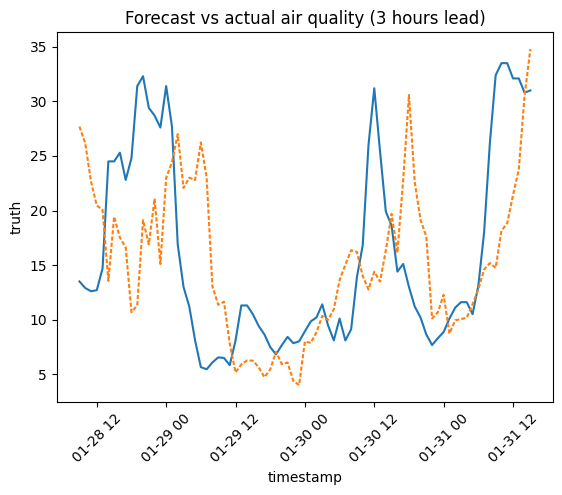

In [52]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)

sns.lineplot(y_hat_df, x="timestamp", y="truth")
sns.lineplot(y_hat_df, x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [53]:
y_hat_df.head()

,timestamp,truth,pred
657,2026-01-28 09:00:00+00:00,13.5,27.692499
658,2026-01-28 10:00:00+00:00,12.9,26.161859
659,2026-01-28 11:00:00+00:00,12.6,22.662394
660,2026-01-28 12:00:00+00:00,12.7,20.448599
661,2026-01-28 13:00:00+00:00,14.7,20.064104


In [54]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,9.136805e-01,pm25
1,5.089786e-01,day_cos
2,2.894210e-01,dew_point
3,9.679316e-02,temp
4,8.836037e-02,lag_pm25_3
5,2.103838e-27,month_cos
6,1.051919e-27,month_sin
7,0.000000e+00,month
8,0.000000e+00,year
9,-5.675660e-03,clouds


In [55]:
df.groupby('month').agg({
    'target': 'mean'
})

,target
month,
1,17.410918


# Final remarks
At the end of this experiment, we observe the following:
- Removing lag and rolling features makes model **useless** (worth than guessing)
- As such, current features (temperature, humidity and temporal features) **do not** have significant explanatory power.
- Further feature engineering is required. Likely candidates:
    - Wind
    - Pressure

# Prophet

In [56]:
from prophet import Prophet

/home/luc/Documents/Projects/air_quality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [57]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [58]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [59]:
m = Prophet()
m.fit(prophet_df)

12:25:26 - cmdstanpy - INFO - Chain [1] start processing
12:25:26 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
773,2026-03-16 15:00:00
774,2026-03-17 15:00:00
775,2026-03-18 15:00:00
776,2026-03-19 15:00:00
777,2026-03-20 15:00:00


In [61]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
773,2026-03-16 15:00:00,-175.560293,-295.919136,-61.158888
774,2026-03-17 15:00:00,-174.046411,-298.523023,-56.232783
775,2026-03-18 15:00:00,-169.533885,-297.656869,-48.067627
776,2026-03-19 15:00:00,-178.295493,-315.017718,-50.485293
777,2026-03-20 15:00:00,-183.072062,-319.355012,-54.310919


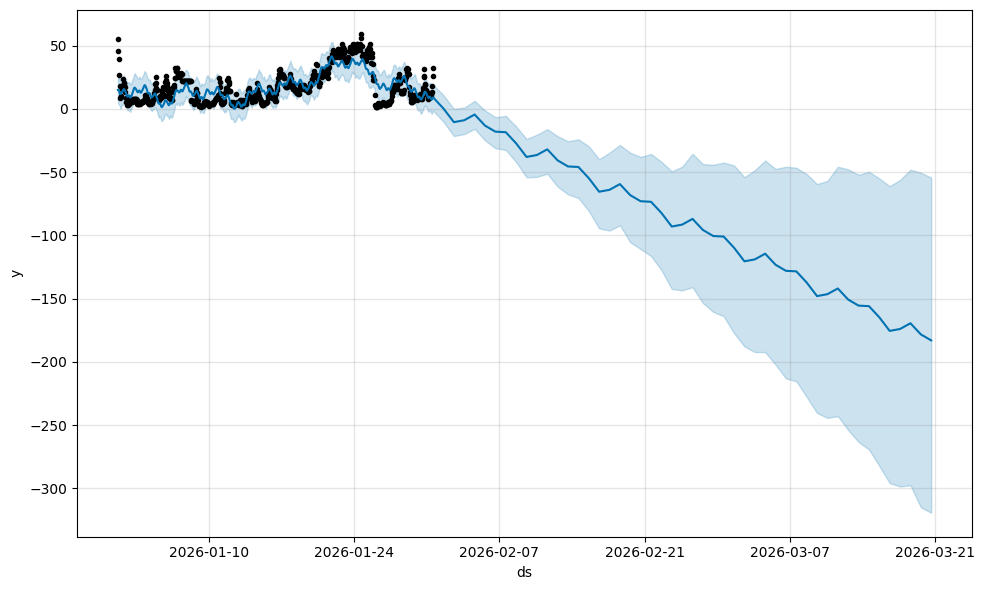

In [62]:
fig1 = m.plot(forecast)

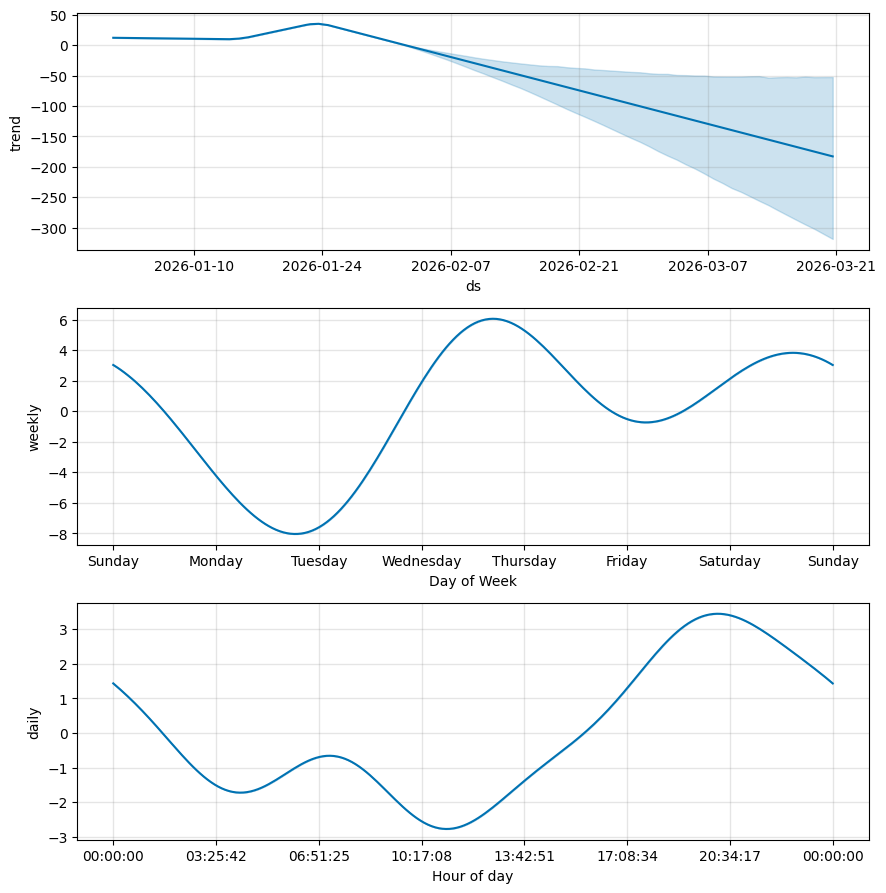

In [63]:
fig2 = m.plot_components(forecast)

In [64]:
df.describe()

,pm25,temp,feels_like,pressure,humidity,dew_point,clouds,wind_speed,wind_deg,wind_gust,...,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos,rolling_pm25_3,lag_pm25_3,lag_pm25_6,target
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,...,7.300000e+02,7.300000e+02,730.0,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,17.412110,272.403027,271.023027,1010.758904,84.349315,270.148644,65.336986,1.561548,179.954795,2.433342,...,3.879385e-03,-9.365664e-03,0.5,0.866025,-0.024934,-0.056714,17.483890,17.684164,19.092110,17.410918
std,13.591544,4.252039,4.520978,9.218247,9.914305,3.854511,38.923461,1.140896,90.954031,1.790058,...,7.069186e-01,7.081913e-01,0.0,0.000000,0.701420,0.711012,13.646034,14.406890,28.598734,13.512985
min,1.470000,260.030000,256.670000,990.000000,47.000000,258.880000,0.000000,0.130000,4.000000,0.450000,...,-1.000000e+00,-1.000000e+00,0.5,0.866025,-0.974928,-0.900969,1.596667,1.470000,1.470000,1.470000
25%,6.330000,269.670000,268.222500,1003.000000,80.000000,267.172500,24.250000,0.890000,86.000000,1.340000,...,-7.071068e-01,-7.071068e-01,0.5,0.866025,-0.781831,-0.900969,6.425000,6.330000,6.330000,6.330000
50%,13.500000,272.755000,271.260000,1012.500000,87.500000,270.730000,85.500000,1.340000,195.000000,2.240000,...,1.224647e-16,-1.836970e-16,0.5,0.866025,0.000000,-0.222521,13.366667,13.500000,13.650000,13.550000
75%,25.075000,275.230000,274.087500,1018.000000,92.000000,272.980000,99.000000,2.167500,265.000000,2.680000,...,7.071068e-01,7.071068e-01,0.5,0.866025,0.781831,0.623490,25.008333,25.250000,25.375000,25.300000
max,59.200000,284.540000,283.220000,1029.000000,99.000000,278.820000,100.000000,8.940000,359.000000,11.620000,...,1.000000e+00,1.000000e+00,0.5,0.866025,0.974928,1.000000,76.066667,102.000000,616.000000,59.200000
